Random Forest

Cross-validation scores: [0.88043478 0.85326087 0.875      0.80327869 0.7431694 ]
Mean CV score: 0.8310287479211214


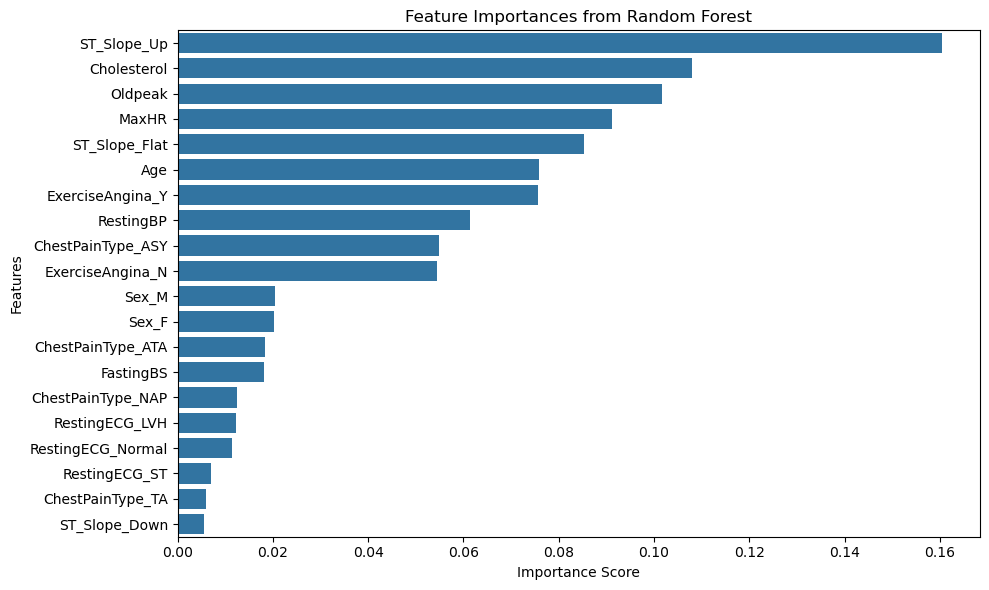

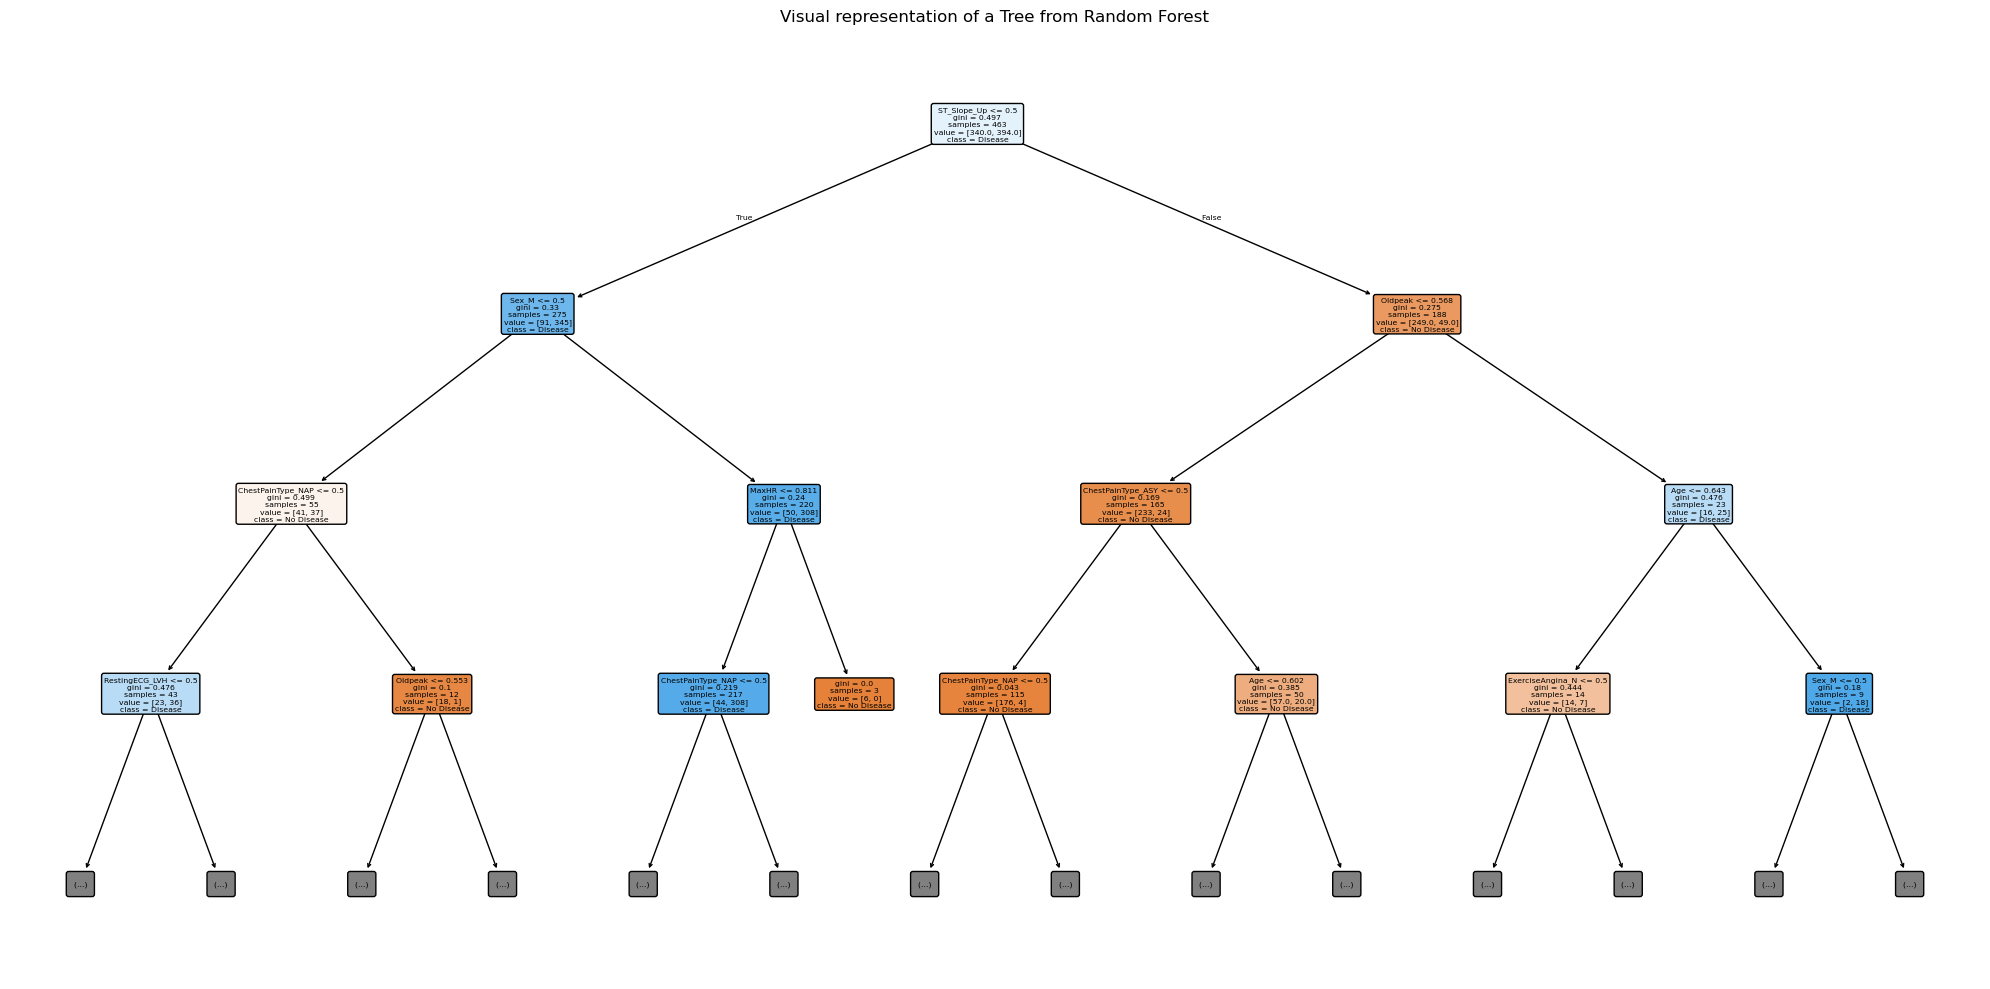

In [48]:
# IMPORT REQUIRED LIBRARIES
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import export_text, plot_tree

# LOAD DATASET
df = pd.read_csv('heart_processed2.csv')

# Separate features and target
x = df.drop('HeartDisease', axis=1)
y = df['HeartDisease'] 

# Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Train random forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

# Cross-validation
cv_scores = cross_val_score(rf_model, x, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

# SAVE TRAINED MODEL
joblib.dump(rf_model, 'random_forest_model.pkl')

# Feature importance visualization
importances = rf_model.feature_importances_
feature_names = x.columns
indices = np.argsort(importances)[::-1] #sorted indices

# Plotting
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Tree structure (pick the first tree in the forest)
plt.figure(figsize=(20, 10))
plot_tree(estimator,
          feature_names=x.columns,
          class_names=['No Disease', 'Disease'],
          filled=True,
          rounded=True,
          max_depth=3)
plt.title("Visual representation of a Tree from Random Forest")
plt.tight_layout()
plt.savefig("random_forest_tree_plot.png")
plt.show()